<a href="https://colab.research.google.com/github/Sona-28/Sentiment-and-Sarcasm-Classification-COMM061/blob/main/NLP_Task2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2.3: Qwen3-1.7B LoRA Adapters For Sarcasm Variations

We have trained three LoRA adapters on the the frozen `Qwen/Qwen3-1.7B` base model:

- UK adapter on `en-UK`
- Indian adapter on `en-IN`
- Australian adapter on `en-AU`

Each setup is trained with two seeds. The validation set is used to choose:

- the best checkpoint
- the best hyperparameter setting from a small grid
- the best sarcasm threshold

We then evaluated the selected runs on all three test varieties and reports the final comparison tables.


## 1. Install Packages

*   List item

*   List item
*   List item


*   List item




In [ ]:
%pip -q install -U \
    transformers>=4.51.0 \
    peft \
    accelerate \
    datasets \
    scikit-learn \
    joblib \
    seaborn


In [ ]:
# Due to issues working in Google Colab, the following cell was added to uninstall torchao,
#  which is a dependency of the peft library. This is a workaround to avoid compatibility
#  issues that arise with torchao in the Colab environment.
%pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


## 2. Mount Google Drive


In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


## 3. Imports And Settings


In [ ]:
import gc
import json
import shutil
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from datasets import Dataset
from IPython.display import display
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, Trainer, TrainingArguments, set_seed
from peft import LoraConfig, TaskType, get_peft_model

sns.set_theme(style='whitegrid')

data_dir = Path('/content/drive/MyDrive/nlp')
base_model = 'Qwen/Qwen3-1.7B'
deployment_artifact_dir = data_dir / 'task2_3_deployment_adapters'
adapter_output_dir = deployment_artifact_dir / 'adapters'


text_column = 'text'
label_column = 'Sarcasm'
variety_column = 'variety'

# Here we've specified the varieties to be used for training and testing, as well as the random seeds for reproducibility.
# We used two seeds to ensure that our results are not dependent on a single random initialization, which can help in assessing the robustness of our model's performance across different runs.
train_varieties = ['en-UK', 'en-IN', 'en-AU']
test_varieties = ['en-UK', 'en-IN', 'en-AU']
seeds = [42, 52]

variety_display_names = {
    'en-UK': 'British',
    'en-IN': 'Indian',
    'en-AU': 'Australian',
}


max_length = 384
train_batch_size = 8
eval_batch_size = 16
gradient_accumulation_steps = 2
weight_decay = 0.01
warmup_ratio = 0.1
logging_steps = 10

# The grid options specify different combinations of learning rates and number of training epochs that we experiment with during the hyperparameter tuning phase.
grid_options = [
    {'learning_rate': 5e-5, 'num_train_epochs': 3},
    {'learning_rate': 1e-4, 'num_train_epochs': 3},
    {'learning_rate': 1e-4, 'num_train_epochs': 4},
]

# We use this threshold grid to evaluate the model's performance at different classification thresholds
# to help with imbalance in the dataset and to find the optimal threshold for classifying sarcasm.
threshold_grid = np.array([0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80])

lora_rank = 16
lora_alpha = 32
lora_dropout = 0.05

torch.set_float32_matmul_precision('high')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

use_bfloat16 = True


## 4. Load Data


In [ ]:
# We load the three splits separately here so that the rest of the notebook can keep training, validation,
#  and test fully separate. This makes it easier to stay organised once we start tuning and comparing runs.
train_data = joblib.load(data_dir / 'train_df.pkl').copy()
validation_data = joblib.load(data_dir / 'val_df.pkl').copy()
test_data = joblib.load(data_dir / 'test_df.pkl').copy()

# This quick type cleanup is mainly to avoid small issues later on when the Trainer and tokenizer expect
#  the labels, text, and variety names to already be in a clean and consistent format.
for frame in [train_data, validation_data, test_data]:
    frame[label_column] = frame[label_column].astype(int)
    frame[text_column] = frame[text_column].astype(str)
    frame[variety_column] = frame[variety_column].astype(str)

display(train_data[[text_column, variety_column, label_column, 'source']].head())


,text,variety,Sarcasm,source
0,I'm a member of the Green Party but I'll be vo...,en-UK,0,Reddit
1,Yeah it blew out to 3x what it was budgeted fo...,en-AU,1,Reddit
2,"Food was pretty great. A little dry, but I am ...",en-AU,0,Google
3,Firstly the staff seemed as if they did n't wa...,en-UK,0,Google
4,We came for lunch and enjoyed the food we orde...,en-UK,0,Google


## 5. Helper Functions


In [ ]:
# This function is just for clearing memory after training and evaluation to ensure that we have enough resources
#  for subsequent runs as we are experimenting with multiple hyperparameter configurations.
def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()

# Here we split the dataset by variety to create separate DataFrames for each variety
# This allows us to train and evaluate our model on specific subsets of the data for the different English varieties (UK, IN, AU).
def split_by_variety(frame):
    return {
        variety: frame[frame[variety_column] == variety].reset_index(drop=True)
        for variety in sorted(frame[variety_column].unique())
    }


def get_class_weights(frame):
    counts = frame[label_column].value_counts().sort_index().reindex([0, 1], fill_value=0)
    total = counts.sum()
    weights = total / (2 * counts)
    return torch.tensor(weights.values, dtype=torch.float32)

# Here we've converted the DataFrame into a Hugging Face Dataset format as it is the expected input format for the Trainer.
def make_dataset(frame):
    frame = frame[[text_column, label_column]].copy().rename(columns={label_column: 'labels'})
    return Dataset.from_pandas(frame, preserve_index=False)

# We chose these metrics (precision, recall, f1-score) to evaluate our model's performance
# because they provide a comprehensive view of how well the model is performing,
#  especially in the context of imbalanced datasets.
def get_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average='macro',
        zero_division=0,
    )
    class_precision, class_recall, class_f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        labels=[0, 1],
        zero_division=0,
    )

    return {
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'non_sarcasm_precision': class_precision[0],
        'non_sarcasm_recall': class_recall[0],
        'non_sarcasm_f1': class_f1[0],
        'sarcasm_precision': class_precision[1],
        'sarcasm_recall': class_recall[1],
        'sarcasm_f1': class_f1[1],
    }


def predict_with_threshold(logits, threshold):
    probabilities = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    predictions = (probabilities[:, 1] >= threshold).astype(int)
    return predictions, probabilities


def get_report_and_matrix(true_labels, predicted_labels):
    report = classification_report(
        true_labels,
        predicted_labels,
        labels=[0, 1],
        target_names=['non-sarcasm', 'sarcasm'],
        output_dict=True,
        zero_division=0,
    )
    matrix = confusion_matrix(true_labels, predicted_labels, labels=[0, 1])
    return report, matrix

# This function iterates over the specified threshold grid to find the best threshold for classifying sarcasm
# based on the evaluation metrics.
def get_best_threshold(logits, true_labels):
    best_choice = None

    for threshold in threshold_grid:
        predicted_labels, probabilities = predict_with_threshold(logits, threshold)
        report, matrix = get_report_and_matrix(true_labels, predicted_labels)
        choice = {
            'threshold': float(threshold),
            'macro_precision': report['macro avg']['precision'],
            'macro_recall': report['macro avg']['recall'],
            'macro_f1': report['macro avg']['f1-score'],
            'non_sarcasm_f1': report['non-sarcasm']['f1-score'],
            'sarcasm_precision': report['sarcasm']['precision'],
            'sarcasm_recall': report['sarcasm']['recall'],
            'sarcasm_f1': report['sarcasm']['f1-score'],
            'probabilities': probabilities,
            'predicted_labels': predicted_labels,
            'matrix': matrix,
        }
        score = (choice['macro_f1'], choice['sarcasm_recall'], choice['sarcasm_f1'])

        if best_choice is None or score > best_choice['score']:
            best_choice = {'score': score, 'choice': choice}

    return best_choice['choice']


def plot_matrix(true_labels, predicted_labels, title):
    matrix = confusion_matrix(true_labels, predicted_labels, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['non-sarcasm', 'sarcasm'],
        yticklabels=['non-sarcasm', 'sarcasm'],
    )
    plt.title(title)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()


## 6. Model Functions


In [ ]:
# We made a custom Trainer here so that class weights can be applied directly in the loss function.
#  This was mainly done because sarcasm is the minority class, so a plain loss could make the model lean too much toward the majority class.
class weighted_trainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss = F.cross_entropy(logits, labels, weight=self.class_weights.to(logits.device))
        return (loss, outputs) if return_outputs else loss


def build_tokenizer():
    tokenizer = AutoTokenizer.from_pretrained(base_model, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = 'right'
    return tokenizer


def tokenize_dataset(dataset, tokenizer):
    dataset = dataset.map(
        lambda batch: tokenizer(batch[text_column], truncation=True, max_length=max_length),
        batched=True,
    )
    dataset.set_format(type='torch')
    return dataset


# In this function we set up the base model and then attach LoRA so that we only train a small part of it.
def build_model(tokenizer):
    model = AutoModelForSequenceClassification.from_pretrained(
        base_model,
        num_labels=2,
        dtype=torch.bfloat16,
    )
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache = False
    model.gradient_checkpointing_enable()

    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=lora_rank,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        bias='none',
        target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],
        modules_to_save=['score'],
    )

    model = get_peft_model(model, lora_config)

    # We cast the trainable parameters back to float32 here because it tends to make training a bit more stable,
    #  even though the main model is loaded in bfloat16 for efficiency.
    for parameter in model.parameters():
        if parameter.requires_grad:
            parameter.data = parameter.data.float()

    return model


def clear_checkpoints():
    for checkpoint in data_dir.glob('checkpoint-*'):
        if checkpoint.is_dir():
            shutil.rmtree(checkpoint, ignore_errors=True)

def write_json(path, data):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w', encoding='utf-8') as file:
        json.dump(data, file, indent=2)


# These helpers create the small deployment bundle used in Task 5.1.
# The base LLM is still loaded from Hugging Face; this folder stores only the tokenizer,
# the selected LoRA adapters, and the per-adapter thresholds chosen on validation data.
def prepare_deployment_artifacts(tokenizer):
    if deployment_artifact_dir.exists():
        shutil.rmtree(deployment_artifact_dir, ignore_errors=True)

    adapter_output_dir.mkdir(parents=True, exist_ok=True)
    tokenizer.save_pretrained(deployment_artifact_dir / 'tokenizer')

    write_json(
        deployment_artifact_dir / 'deployment_config.json',
        {
            'base_model': base_model,
            'task': 'sarcasm_detection',
            'label_map': {
                '0': 'non-sarcasm',
                '1': 'sarcasm',
            },
            'tokenizer_path': 'tokenizer',
            'adapters': {},
        },
    )


def export_deployment_adapter(model, adapter_variety, metadata):
    adapter_dir = adapter_output_dir / adapter_variety
    if adapter_dir.exists():
        shutil.rmtree(adapter_dir, ignore_errors=True)

    model.save_pretrained(adapter_dir)
    write_json(adapter_dir / 'deployment_metadata.json', metadata)

    config_path = deployment_artifact_dir / 'deployment_config.json'
    with config_path.open('r', encoding='utf-8') as file:
        deployment_config = json.load(file)

    deployment_config['adapters'][adapter_variety] = {
        'display_name': variety_display_names.get(adapter_variety, adapter_variety),
        'adapter_path': f'adapters/{adapter_variety}',
        'selected_threshold': metadata['selected_threshold'],
        'seed': metadata['seed'],
        'learning_rate': metadata['learning_rate'],
        'num_train_epochs': metadata['num_train_epochs'],
        'validation_macro_f1': metadata['validation_macro_f1'],
        'validation_sarcasm_recall': metadata['validation_sarcasm_recall'],
        'validation_sarcasm_f1': metadata['validation_sarcasm_f1'],
    }
    write_json(config_path, deployment_config)



## 7. Prepare Train, Validation, And Test Sets


In [ ]:
# We split everything by variety ahead of time so that each adapter is trained on only one variety at a time.
train_sets = split_by_variety(train_data)
validation_sets = split_by_variety(validation_data)
test_sets = split_by_variety(test_data)

# These class weights are calculated separately for each training variety because the label balance is not exactly the same in every subset.
class_weights = {
    variety: get_class_weights(train_sets[variety])
    for variety in train_varieties
}

tokenizer = build_tokenizer()
prepare_deployment_artifacts(tokenizer)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)

# We tokenise and store the datasets once here so we do not have to repeat that work inside every training run.
#  That keeps the main experiment cell cleaner and avoids extra overhead while looping over seeds and options.
tokenized_train_sets = {}
tokenized_validation_sets = {}
tokenized_test_sets = {}

for variety in train_varieties:
    tokenized_train_sets[variety] = tokenize_dataset(make_dataset(train_sets[variety]), tokenizer)
    tokenized_validation_sets[variety] = tokenize_dataset(make_dataset(validation_sets[variety]), tokenizer)

for variety in test_varieties:
    tokenized_test_sets[variety] = tokenize_dataset(make_dataset(test_sets[variety]), tokenizer)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/1145 [00:00<?, ? examples/s]

Map:   0%|          | 0/95 [00:00<?, ? examples/s]

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Map:   0%|          | 0/816 [00:00<?, ? examples/s]

Map:   0%|          | 0/667 [00:00<?, ? examples/s]

## 8. Train, Tune, And Evaluate


In [ ]:
# These lists are used to store every trial as well as the final selected runs.
#  We kept both because one is useful for showing the full tuning process, while the other is what we actually report in the end.
all_trial_rows = []
selected_run_rows = []
test_result_rows = []
confusion_data = {}
deployment_best_scores = {}

for adapter_variety in train_varieties:
    print(f'Adapter variety: {adapter_variety}')
    for seed in seeds:
        best_run = None

        for option_id, option in enumerate(grid_options, start=1):
            # Before each new run we clear memory and old checkpoints so that each option starts as cleanly as possible.
            #  This also helps avoid leftover files or GPU usage from interfering with the next run.
            clear_memory()
            clear_checkpoints()
            set_seed(seed)

            model = build_model(tokenizer)

            learning_rate = option['learning_rate']
            num_train_epochs = option['num_train_epochs']

            print(
                f'  Seed {seed} | option {option_id}/{len(grid_options)} | '
                f'lr={learning_rate} | epochs={num_train_epochs}'
            )

            effective_batch_size = train_batch_size * gradient_accumulation_steps
            steps_per_epoch = max(1, int(np.ceil(len(tokenized_train_sets[adapter_variety]) / effective_batch_size)))
            total_steps = steps_per_epoch * num_train_epochs
            warmup_steps = max(1, int(total_steps * warmup_ratio))

            training_arguments = TrainingArguments(
                output_dir=str(data_dir),
                seed=seed,
                data_seed=seed,
                learning_rate=learning_rate,
                weight_decay=weight_decay,
                warmup_steps=warmup_steps,
                num_train_epochs=num_train_epochs,
                per_device_train_batch_size=train_batch_size,
                per_device_eval_batch_size=eval_batch_size,
                gradient_accumulation_steps=gradient_accumulation_steps,
                bf16=use_bfloat16,
                logging_steps=logging_steps,
                eval_strategy='epoch',
                save_strategy='epoch',
                save_total_limit=1,
                load_best_model_at_end=True,
                metric_for_best_model='eval_macro_f1',
                greater_is_better=True,
                report_to='none',
                remove_unused_columns=True,
                optim='adamw_torch',
            )

            trainer = weighted_trainer(
                model=model,
                args=training_arguments,
                train_dataset=tokenized_train_sets[adapter_variety],
                eval_dataset=tokenized_validation_sets[adapter_variety],
                data_collator=data_collator,
                compute_metrics=get_metrics,
                class_weights=class_weights[adapter_variety],
            )

            train_result = trainer.train()

            # We use the validation predictions here to choose a threshold after training rather than just assuming 0.5.
            #  This was added because the dataset is imbalanced and a custom threshold can sometimes recover sarcasm examples better.
            validation_output = trainer.predict(tokenized_validation_sets[adapter_variety], metric_key_prefix='validation')
            best_threshold = get_best_threshold(validation_output.predictions, validation_output.label_ids)

            trial_row = {
                'adapter_variety': adapter_variety,
                'seed': seed,
                'option_id': option_id,
                'learning_rate': learning_rate,
                'num_train_epochs': num_train_epochs,
                'train_loss': float(train_result.training_loss),
                'best_checkpoint_macro_f1': float(trainer.state.best_metric),
                'selected_threshold': best_threshold['threshold'],
                'validation_macro_precision': best_threshold['macro_precision'],
                'validation_macro_recall': best_threshold['macro_recall'],
                'validation_macro_f1': best_threshold['macro_f1'],
                'validation_non_sarcasm_f1': best_threshold['non_sarcasm_f1'],
                'validation_sarcasm_precision': best_threshold['sarcasm_precision'],
                'validation_sarcasm_recall': best_threshold['sarcasm_recall'],
                'validation_sarcasm_f1': best_threshold['sarcasm_f1'],
            }
            all_trial_rows.append(trial_row)

            candidate_test_rows = []
            candidate_confusion_data = {}

            # We evaluate the same trained adapter on all test varieties so that we can compare both same-variety performance
            #  and cross-variety transfer in one run.
            for test_variety in test_varieties:
                test_output = trainer.predict(tokenized_test_sets[test_variety], metric_key_prefix='test')
                predicted_labels, probabilities = predict_with_threshold(
                    test_output.predictions,
                    best_threshold['threshold'],
                )
                report, matrix = get_report_and_matrix(test_output.label_ids, predicted_labels)

                candidate_test_rows.append({
                    'adapter_variety': adapter_variety,
                    'seed': seed,
                    'learning_rate': learning_rate,
                    'num_train_epochs': num_train_epochs,
                    'selected_threshold': best_threshold['threshold'],
                    'test_variety': test_variety,
                    'n_test': len(test_output.label_ids),
                    'macro_precision': report['macro avg']['precision'],
                    'macro_recall': report['macro avg']['recall'],
                    'macro_f1': report['macro avg']['f1-score'],
                    'non_sarcasm_precision': report['non-sarcasm']['precision'],
                    'non_sarcasm_recall': report['non-sarcasm']['recall'],
                    'non_sarcasm_f1': report['non-sarcasm']['f1-score'],
                    'sarcasm_precision': report['sarcasm']['precision'],
                    'sarcasm_recall': report['sarcasm']['recall'],
                    'sarcasm_f1': report['sarcasm']['f1-score'],
                    'confusion_00': int(matrix[0, 0]),
                    'confusion_01': int(matrix[0, 1]),
                    'confusion_10': int(matrix[1, 0]),
                    'confusion_11': int(matrix[1, 1]),
                })

                candidate_confusion_data[(adapter_variety, seed, test_variety)] = (
                    test_output.label_ids,
                    predicted_labels,
                )

            selection_score = (
                trial_row['validation_macro_f1'],
                trial_row['validation_sarcasm_recall'],
                trial_row['validation_sarcasm_f1'],
            )

            selected_row = {
                'adapter_variety': adapter_variety,
                'seed': seed,
                'learning_rate': learning_rate,
                'num_train_epochs': num_train_epochs,
                'selected_threshold': best_threshold['threshold'],
                'train_samples': len(tokenized_train_sets[adapter_variety]),
                'validation_samples': len(tokenized_validation_sets[adapter_variety]),
                'train_loss': float(train_result.training_loss),
                'validation_macro_precision': best_threshold['macro_precision'],
                'validation_macro_recall': best_threshold['macro_recall'],
                'validation_macro_f1': best_threshold['macro_f1'],
                'validation_non_sarcasm_f1': best_threshold['non_sarcasm_f1'],
                'validation_sarcasm_precision': best_threshold['sarcasm_precision'],
                'validation_sarcasm_recall': best_threshold['sarcasm_recall'],
                'validation_sarcasm_f1': best_threshold['sarcasm_f1'],
            }

            if best_run is None or selection_score > best_run['selection_score']:
                best_run = {
                    'selection_score': selection_score,
                    'selected_row': selected_row,
                    'test_rows': candidate_test_rows,
                    'confusion_rows': candidate_confusion_data,
                }

            # For deployment we keep only one final adapter per variety: the strongest validation run
            # across all seeds and hyperparameter options. Saving here avoids retraining later.
            if adapter_variety not in deployment_best_scores or selection_score > deployment_best_scores[adapter_variety]:
                deployment_best_scores[adapter_variety] = selection_score
                export_deployment_adapter(
                    trainer.model,
                    adapter_variety,
                    {
                        'base_model': base_model,
                        'adapter_variety': adapter_variety,
                        'display_name': variety_display_names.get(adapter_variety, adapter_variety),
                        'seed': int(seed),
                        'learning_rate': float(learning_rate),
                        'num_train_epochs': int(num_train_epochs),
                        'selected_threshold': float(best_threshold['threshold']),
                        'selection_score': [float(value) for value in selection_score],
                        'train_samples': int(len(tokenized_train_sets[adapter_variety])),
                        'validation_samples': int(len(tokenized_validation_sets[adapter_variety])),
                        'validation_macro_precision': float(best_threshold['macro_precision']),
                        'validation_macro_recall': float(best_threshold['macro_recall']),
                        'validation_macro_f1': float(best_threshold['macro_f1']),
                        'validation_non_sarcasm_f1': float(best_threshold['non_sarcasm_f1']),
                        'validation_sarcasm_precision': float(best_threshold['sarcasm_precision']),
                        'validation_sarcasm_recall': float(best_threshold['sarcasm_recall']),
                        'validation_sarcasm_f1': float(best_threshold['sarcasm_f1']),
                    },
                )

            del trainer
            del model
            clear_memory()
            clear_checkpoints()

        selected_run_rows.append(best_run['selected_row'])
        test_result_rows.extend(best_run['test_rows'])
        confusion_data.update(best_run['confusion_rows'])

trial_results = pd.DataFrame(all_trial_rows)
selected_runs = pd.DataFrame(selected_run_rows)
test_results = pd.DataFrame(test_result_rows)



Adapter variety: en-UK


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-1.7B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Epoch,Training Loss,Validation Loss,Macro Precision,Macro Recall,Macro F1,Non Sarcasm Precision,Non Sarcasm Recall,Non Sarcasm F1,Sarcasm Precision,Sarcasm Recall,Sarcasm F1
1,1.279303,0.537649,0.726667,0.771855,0.721930,0.920000,0.686567,0.786325,0.533333,0.857143,0.657534
2,0.726723,0.490967,0.767707,0.806237,0.777846,0.913793,0.791045,0.848000,0.621622,0.821429,0.707692
3,0.533840,0.478044,0.774349,0.803305,0.784526,0.901639,0.820896,0.859375,0.647059,0.785714,0.709677


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-1.7B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Seed 52 | option 3/3 | lr=0.0001 | epochs=4


Epoch,Training Loss,Validation Loss,Macro Precision,Macro Recall,Macro F1,Non Sarcasm Precision,Non Sarcasm Recall,Non Sarcasm F1,Sarcasm Precision,Sarcasm Recall,Sarcasm F1
1,1.294483,0.544667,0.728502,0.774787,0.714912,0.936170,0.656716,0.771930,0.520833,0.892857,0.657895
2,0.756041,0.472200,0.767707,0.806237,0.777846,0.913793,0.791045,0.848000,0.621622,0.821429,0.707692
3,0.507364,0.542841,0.751446,0.777985,0.760585,0.885246,0.805970,0.843750,0.617647,0.750000,0.677419
4,0.301265,0.895593,0.723077,0.731876,0.727011,0.846154,0.820896,0.833333,0.600000,0.642857,0.620690


## 9. Validation Tuning Results

This table shows all of the validation runs for each LoRA adapter. I used the validation set for model selection because it is the split reserved for choosing the best run before looking at the final test performance.


In [ ]:
variety_order = pd.CategoricalDtype(train_varieties, ordered=True)

validation_results = trial_results.copy()
validation_results['adapter_variety'] = validation_results['adapter_variety'].astype(variety_order)
validation_results = validation_results.sort_values(['adapter_variety', 'seed', 'option_id']).reset_index(drop=True)
validation_results['adapter_variety'] = validation_results['adapter_variety'].astype(str)

display(validation_results)


,adapter_variety,seed,option_id,learning_rate,num_train_epochs,train_loss,best_checkpoint_macro_f1,selected_threshold,validation_macro_precision,validation_macro_recall,validation_macro_f1,validation_non_sarcasm_f1,validation_sarcasm_precision,validation_sarcasm_recall,validation_sarcasm_f1
0,en-UK,42,1,0.00005,3,0.749485,0.730143,0.45,0.688372,0.826613,0.730143,0.938547,0.400000,0.750000,0.521739
1,en-UK,42,2,0.00010,3,0.624233,0.748927,0.60,0.712868,0.889113,0.763577,0.943820,0.437500,0.875000,0.583333
2,en-UK,42,3,0.00010,4,0.511797,0.748927,0.45,0.699930,0.883737,0.748927,0.937853,0.411765,0.875000,0.560000
3,en-UK,52,1,0.00005,3,1.040969,0.647674,0.60,0.629202,0.747984,0.657627,0.915254,0.294118,0.625000,0.400000
4,en-UK,52,2,0.00010,3,0.811487,0.667033,0.30,0.664566,0.815860,0.703277,0.926554,0.352941,0.750000,0.480000
5,en-UK,52,3,0.00010,4,0.675348,0.692128,0.45,0.660000,0.908602,0.692128,0.899408,0.320000,1.000000,0.484848
6,en-IN,42,1,0.00005,3,0.978131,0.671963,0.55,0.681308,0.722477,0.699074,0.953704,0.400000,0.500000,0.444444
7,en-IN,42,2,0.00010,3,0.838273,0.759259,0.70,0.815315,0.740826,0.772078,0.972727,0.666667,0.500000,0.571429
8,en-IN,42,3,0.00010,4,0.678174,0.671963,0.75,0.777679,0.678326,0.714932,0.968326,0.600000,0.375000,0.461538
9,en-IN,52,1,0.00005,3,1.267517,0.734803,0.55,0.721154,0.842890,0.764588,0.957746,0.461538,0.750000,0.571429


From the full validation table, we then keep one final model for each variety. The main selection score is validation macro-F1, because the sarcasm data is imbalanced and macro-F1 gives both classes equal weight. If there is a tie, we use sarcasm recall and then sarcasm F1 as tie-breakers.


In [ ]:
selection_columns = ['validation_macro_f1', 'validation_sarcasm_recall', 'validation_sarcasm_f1']

final_selected_models = (
    trial_results.sort_values(
        ['adapter_variety', *selection_columns],
        ascending=[True, False, False, False],
    )
    .groupby('adapter_variety', as_index=False)
    .head(1)
    .reset_index(drop=True)
)
final_selected_models['adapter_variety'] = final_selected_models['adapter_variety'].astype(variety_order)
final_selected_models = final_selected_models.sort_values('adapter_variety')
final_selected_models['adapter_variety'] = final_selected_models['adapter_variety'].astype(str)

selected_model_columns = [
    'adapter_variety',
    'seed',
    'option_id',
    'learning_rate',
    'num_train_epochs',
    'selected_threshold',
    'validation_macro_f1',
    'validation_sarcasm_recall',
    'validation_sarcasm_f1',
]

display(final_selected_models[selected_model_columns])


,adapter_variety,seed,option_id,learning_rate,num_train_epochs,selected_threshold,validation_macro_f1,validation_sarcasm_recall,validation_sarcasm_f1
2,en-UK,42,2,0.0001,3,0.6,0.763577,0.875000,0.583333
1,en-IN,42,2,0.0001,3,0.7,0.772078,0.500000,0.571429
0,en-AU,52,2,0.0001,3,0.3,0.808853,0.964286,0.760563


The selected models are the following as can be seen from the table:

- en-UK: seed 42, validation macro-F1 0.763577, threshold 0.60
- en-IN: seed 42, validation macro-F1 0.772078, threshold 0.70
- en-AU: seed 52, validation macro-F1 0.808853, threshold 0.30

## 10. Test Results For Selected Models


In [ ]:
key_columns = ['adapter_variety', 'seed', 'learning_rate', 'num_train_epochs', 'selected_threshold']

selected_test_results = test_results.merge(
    final_selected_models[key_columns],
    on=key_columns,
    how='inner',
)
selected_test_results['adapter_variety'] = selected_test_results['adapter_variety'].astype(variety_order)
selected_test_results['test_variety'] = selected_test_results['test_variety'].astype(variety_order)
selected_test_results = selected_test_results.sort_values(['adapter_variety', 'test_variety']).reset_index(drop=True)
selected_test_results['adapter_variety'] = selected_test_results['adapter_variety'].astype(str)
selected_test_results['test_variety'] = selected_test_results['test_variety'].astype(str)

selected_test_columns = [
    'adapter_variety',
    'seed',
    'learning_rate',
    'num_train_epochs',
    'selected_threshold',
    'test_variety',
    'macro_precision',
    'macro_recall',
    'macro_f1',
    'non_sarcasm_precision',
    'non_sarcasm_recall',
    'non_sarcasm_f1',
    'sarcasm_precision',
    'sarcasm_recall',
    'sarcasm_f1',
]

display(selected_test_results[selected_test_columns])


,adapter_variety,seed,learning_rate,num_train_epochs,selected_threshold,test_variety,macro_precision,macro_recall,macro_f1,non_sarcasm_precision,non_sarcasm_recall,non_sarcasm_f1,sarcasm_precision,sarcasm_recall,sarcasm_f1
0,en-UK,42,0.0001,3,0.6,en-UK,0.674133,0.738036,0.699047,0.961600,0.928903,0.944969,0.386667,0.547170,0.453125
1,en-UK,42,0.0001,3,0.6,en-IN,0.588449,0.764474,0.591277,0.976898,0.778947,0.866764,0.200000,0.750000,0.315789
2,en-UK,42,0.0001,3,0.6,en-AU,0.612543,0.574695,0.575926,0.743268,0.878981,0.805447,0.481818,0.270408,0.346405
3,en-IN,42,0.0001,3,0.7,en-UK,0.777818,0.544851,0.562923,0.930636,0.995363,0.961912,0.625000,0.094340,0.163934
4,en-IN,42,0.0001,3,0.7,en-IN,0.612585,0.601316,0.606518,0.945170,0.952632,0.948886,0.280000,0.250000,0.264151
5,en-IN,42,0.0001,3,0.7,en-AU,0.495887,0.499794,0.421877,0.706061,0.989384,0.824050,0.285714,0.010204,0.019704
6,en-AU,52,0.0001,3,0.3,en-UK,0.594668,0.813275,0.567100,0.993258,0.683153,0.809524,0.196078,0.943396,0.324675
7,en-AU,52,0.0001,3,0.3,en-IN,0.555506,0.710338,0.493022,0.977083,0.617105,0.756452,0.133929,0.803571,0.229592
8,en-AU,52,0.0001,3,0.3,en-AU,0.734726,0.780585,0.734480,0.920110,0.709130,0.800959,0.549342,0.852041,0.668000


## 11. Confusion Matrices


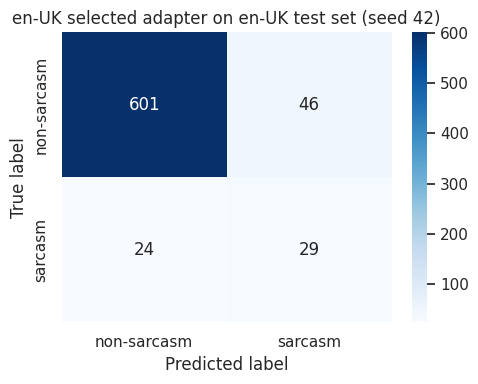

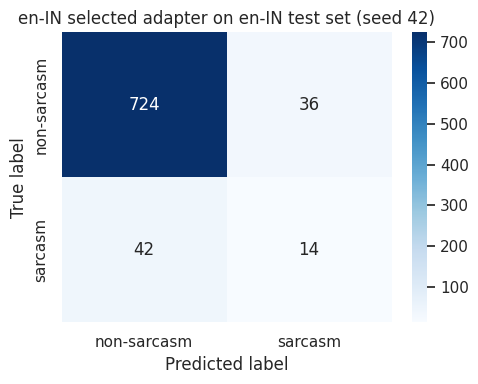

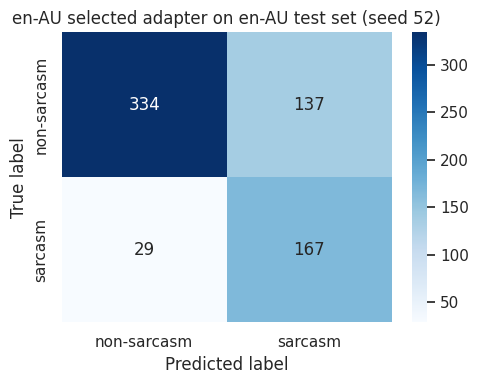

In [ ]:
# These matrices use the validation-selected adapters and show their same-variety test performance.
for _, selected_model in final_selected_models.iterrows():
    adapter_variety = selected_model['adapter_variety']
    seed = int(selected_model['seed'])

    row = selected_test_results[
        (selected_test_results['adapter_variety'] == adapter_variety)
        & (selected_test_results['seed'] == seed)
        & (selected_test_results['test_variety'] == adapter_variety)
    ].iloc[0]

    matrix = np.array([
        [int(row['confusion_00']), int(row['confusion_01'])],
        [int(row['confusion_10']), int(row['confusion_11'])],
    ])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['non-sarcasm', 'sarcasm'],
        yticklabels=['non-sarcasm', 'sarcasm'],
    )
    plt.title(f'{adapter_variety} selected adapter on {adapter_variety} test set (seed {seed})')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()


## 12. Final Summary Table


In [ ]:
summary_table = selected_test_results[
    [
        'adapter_variety',
        'test_variety',
        'macro_f1',
        'macro_precision',
        'macro_recall',
        'non_sarcasm_f1',
        'sarcasm_f1',
        'sarcasm_recall',
    ]
].copy()

summary_table['adapter_variety'] = summary_table['adapter_variety'].astype(variety_order)
summary_table['test_variety'] = summary_table['test_variety'].astype(variety_order)
summary_table = summary_table.sort_values(['adapter_variety', 'test_variety']).reset_index(drop=True)
summary_table['adapter_variety'] = summary_table['adapter_variety'].astype(str)
summary_table['test_variety'] = summary_table['test_variety'].astype(str)

display(summary_table)


,adapter_variety,test_variety,macro_f1,macro_precision,macro_recall,non_sarcasm_f1,sarcasm_f1,sarcasm_recall
0,en-UK,en-UK,0.699047,0.674133,0.738036,0.944969,0.453125,0.547170
1,en-UK,en-IN,0.591277,0.588449,0.764474,0.866764,0.315789,0.750000
2,en-UK,en-AU,0.575926,0.612543,0.574695,0.805447,0.346405,0.270408
3,en-IN,en-UK,0.562923,0.777818,0.544851,0.961912,0.163934,0.094340
4,en-IN,en-IN,0.606518,0.612585,0.601316,0.948886,0.264151,0.250000
5,en-IN,en-AU,0.421877,0.495887,0.499794,0.824050,0.019704,0.010204
6,en-AU,en-UK,0.567100,0.594668,0.813275,0.809524,0.324675,0.943396
7,en-AU,en-IN,0.493022,0.555506,0.710338,0.756452,0.229592,0.803571
8,en-AU,en-AU,0.734480,0.734726,0.780585,0.800959,0.668000,0.852041


## 13. Heatmap


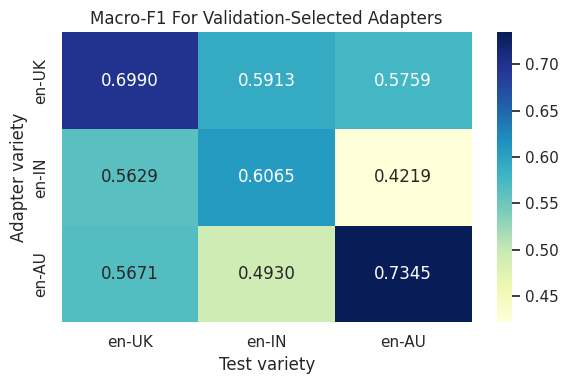

In [ ]:
heatmap_values = summary_table.pivot(index='adapter_variety', columns='test_variety', values='macro_f1')
heatmap_values = heatmap_values.loc[train_varieties, train_varieties]

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_values, annot=True, fmt='.4f', cmap='YlGnBu')
plt.title('Macro-F1 For Validation-Selected Adapters')
plt.xlabel('Test variety')
plt.ylabel('Adapter variety')
plt.tight_layout()
plt.show()


## Deployment Files

Here we save the files needed later for deployment. The folder contains the tokenizer, the selected LoRA adapter for each English variety, and a JSON config file. The JSON file stores the base model name, the adapter paths, and the selected threshold for each adapter.

In [ ]:
deployment_config_path = deployment_artifact_dir / 'deployment_config.json'

if deployment_config_path.exists():
    with deployment_config_path.open('r', encoding='utf-8') as file:
        deployment_config = json.load(file)

    adapter_summary = pd.DataFrame.from_dict(deployment_config['adapters'], orient='index')
    display(adapter_summary)
else:
    display(pd.DataFrame([{
        'status': 'Run the training/evaluation cell first so the selected adapters can be exported.',
        'expected_folder': str(deployment_artifact_dir),
    }]))


,display_name,adapter_path,selected_threshold,seed,learning_rate,num_train_epochs,validation_macro_f1,validation_sarcasm_recall,validation_sarcasm_f1
en-UK,British,adapters/en-UK,0.6,42,0.0001,3,0.763577,0.875000,0.583333
en-IN,Indian,adapters/en-IN,0.7,42,0.0001,3,0.772078,0.500000,0.571429
en-AU,Australian,adapters/en-AU,0.3,52,0.0001,3,0.808853,0.964286,0.760563
